# Task 2: Credit Risk Prediction 

Dataset(loan_default_prediction)

According to given instruction, I have to:
1. Handle missing data appropriately
2. Visualize the key features such as loan_amount, education/employment_status, and income
3. Train a classification model like Logistic Regression or Decision Tree
4. Evaluate the model using accuracy and a confusion matrix

# Summary
The main objective focuses on predicting whether a loan applicant is likely to default using machine learning. With increasing loan applications, it has become important for banks to make fast, and data-driven decisions. This project aims to build a predictive model using historical applicant data such as income, loan_amount and employment status. By analyzing these features, the model helps improving loan approval decisions and reducing finanicial losses.


In [1]:
#importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

#loading dataset
data = pd.read_csv("loan_default_prediction.csv")
print("\n Complete structure of dataset:")
print(data)
print("\n First five rows:")
print(data.head())


 Complete structure of dataset:
      loan_id     income  loan_amount employment_status  default
0    LOAN0001   33001.29     46106.58          Employed        0
1    LOAN0002  111203.94    446197.60          Employed        1
2    LOAN0003    5635.65      3546.47        Unemployed        1
3    LOAN0004   97349.41    348804.41          Employed        0
4    LOAN0005    9408.81     28132.18        Unemployed        0
..        ...        ...          ...               ...      ...
995  LOAN0996   12709.24      7790.65        Unemployed        1
996  LOAN0997   21530.28     65578.60        Unemployed        1
997  LOAN0998  135330.32    266183.55          Employed        0
998  LOAN0999   87868.91     58128.94          Employed        0
999  LOAN1000  137636.27    387660.34          Employed        0

[1000 rows x 5 columns]

 First five rows:
    loan_id     income  loan_amount employment_status  default
0  LOAN0001   33001.29     46106.58          Employed        0
1  LOAN0002  1112

# Handling missing values and preprocessing

loan_id column is not necessary for our prediction. so, we remove this column first

In [2]:
#remove loan_id column using drop() function
data.drop('loan_id',axis=1, inplace=True)

In [3]:
print(data.columns.tolist())

['income', 'loan_amount', 'employment_status', 'default']


In [4]:
data.isnull().sum().sort_values(ascending = False)

income               0
loan_amount          0
employment_status    0
default              0
dtype: int64

We can see there is no missing value in our dataset

In [5]:
# encoding employment_status column to numeric
data['employment_status']= data['employment_status'].map({'Employed':1, 'Unemployed':0})
data.head()

,income,loan_amount,employment_status,default
0,33001.29,46106.58,1,0
1,111203.94,446197.60,1,1
2,5635.65,3546.47,0,1
3,97349.41,348804.41,1,0
4,9408.81,28132.18,0,0


# Visualization
Pie Chart

This pie chart shows the percentage of loan_defaulters and non_defaulters in dataset

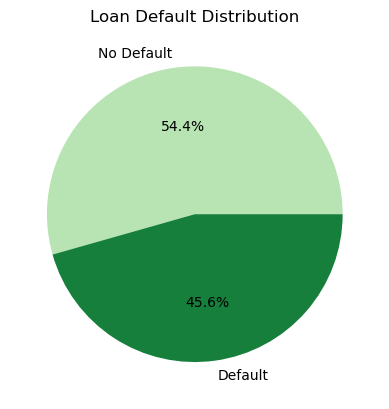

In [6]:
colors = plt.cm.Greens([0.3,0.8])
data['default'].value_counts().plot.pie(
    autopct = '%1.1f%%',
    colors = colors,
    labels = ['No Default', 'Default']
)
plt.title("Loan Default Distribution")
plt.ylabel("")
plt.show()

# Count Plot
This plot shows how employment_status effects loan default behaviour

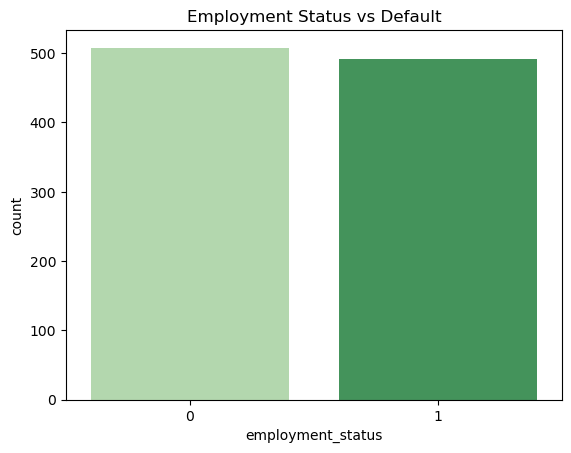

In [8]:
sns.countplot(x = "employment_status", data = data, palette = "Greens")
plt.title("Employment Status vs Default")
plt.show()

# Box plot

This boxplot show how income differs between people who default and those who do not default, helping us understand risk patterns

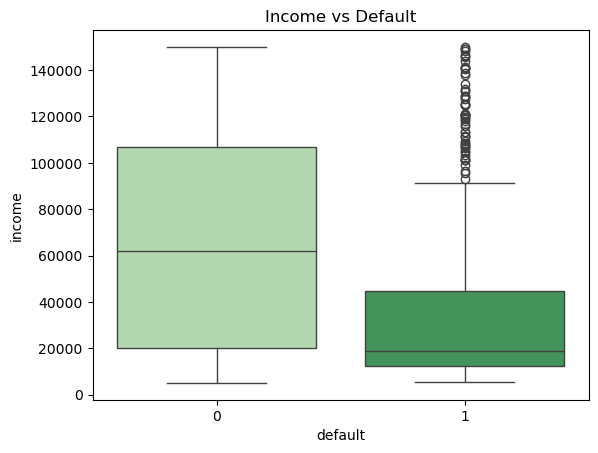

In [10]:
sns.boxplot(x = "default", y="income", data = data, palette = "Greens")
plt.title("Income vs Default")
plt.show()

# Heat map

The correlation heatmap shows that income has negative relationship with loan default, indicating higher the income reducing the likelihood of default. Loan amount has positive relationship with default, suggesting that higger the loan amount increase default risk.

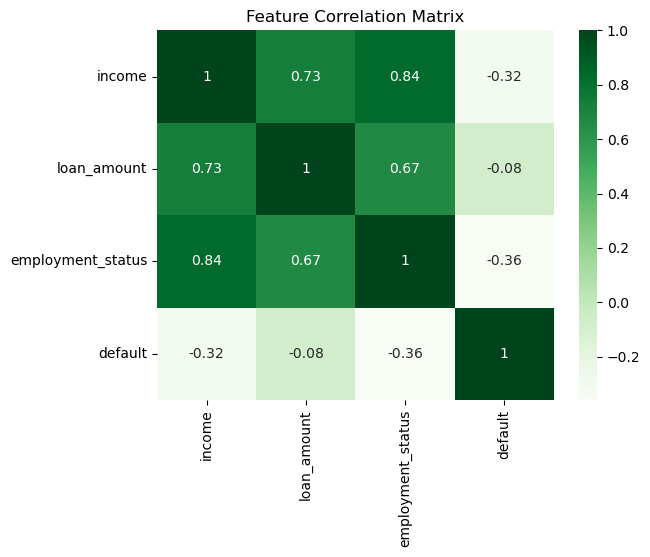

In [11]:
sns.heatmap(data.corr(), annot = True, cmap = "Greens")
plt.title("Feature Correlation Matrix")
plt.show()

# Line bar

linebar clearly shows that default increases if the employment rate is increased

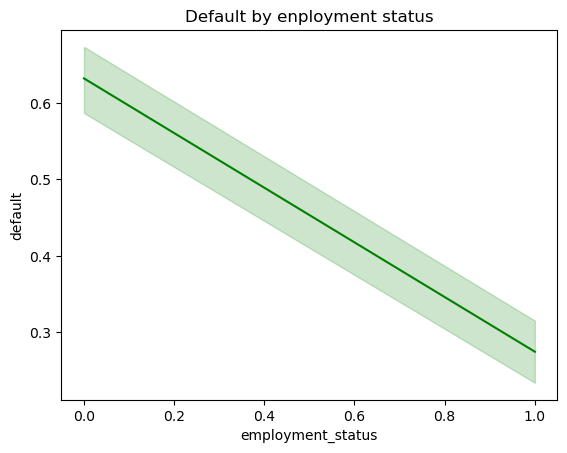

In [12]:
sns.lineplot(x = "employment_status", y = "default", data = data, color = "green")
plt.title("Default by enployment status")
plt.show()

# Classification Model

we use logistic regression with max_2000 iterations because our problem is of binary clasification and we see that we will get better accuracy in our model rather than DecisionTreeClassifier

In [13]:
X = data[['income','loan_amount','employment_status']]
y = data['default']

#train test split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)

# Feature Scalling/Standard Scalling

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Load/ call the logistic regression model
model = LogisticRegression(max_iter = 2000, solver = "liblinear", class_weight = "balanced")

#train the model
model.fit(X_train_scaled, y_train)
model.predict(X_test)

array([1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [17]:
y_pred = model.predict(X_test_scaled)
print(y_pred)

[1 0 1 0 1 1 0 0 0 1 0 0 1 1 1 0 0 0 0 1 1 0 0 1 1 1 0 0 1 0 1 1 0 0 1 0 1
 0 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 1 1 1 0 1 0 1 1 0 0 1 1 0
 1 1 0 0 1 1 0 0 0 1 1 0 1 1 0 0 1 1 0 0 0 1 1 1 0 0 1 0 0 1 0 0 1 1 0 1 1
 1 1 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 1 1 0
 1 1 0 1 1 1 0 0 0 1 0 1 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 1 1 0 1 1 0 0 0 1
 1 0 1 1 0 0 1 1 1 1 0 1 1 0 1]


# Prediction for unknown values

In [18]:
# let's predict for known values
print(model.predict([[7390,38545,0]]))

[1]


In [23]:
# let's predict for unknown values
print(model.predict([[80000,65000,1]]))

[0]


# Evaluation of Model
# Accuracy_score

In [24]:
# Checking accuracy score
from sklearn.metrics import accuracy_score
y_predict = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.695


We can see that accuracy score is 69% 

# Confusion Matrix
Confusion matrix checks how many predictions are correct and incorrect

In [30]:
# for confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[71 38]
 [23 68]]


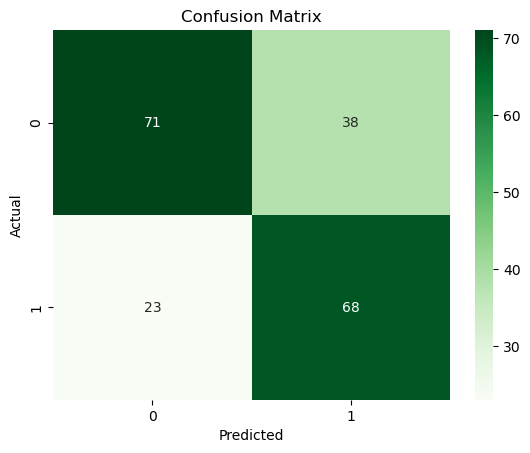

In [33]:
# Graphical representation of confusion matrix by heatmap
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification report

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.695
Confusion Matrix:
 [[71 38]
 [23 68]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.65      0.70       109
           1       0.64      0.75      0.69        91

    accuracy                           0.69       200
   macro avg       0.70      0.70      0.69       200
weighted avg       0.70      0.69      0.70       200



# Conclusion


The dataset was preprocessed by encoding categorical variables and aplying feature scaling using StandardScaler. A Logistic Regression model was train to predict the loan default risk. Stratified sampling was used in train-test split to maintain class distribution which improve model performance. The final model acheived an accuracy of 69%, indicating that the model correctly predicts the loan default status for the majority of case.
Evaluation  using confusion matrix and classification report showed that the model performes reasonably well in identifying both defaulters and non-defaulters.